In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import matplotlib.pyplot as plt
%matplotlib inline
                                                              

In [34]:
def download(url,filename):
    r = requests.get(url)
    if r.status_code == 200:
        with open(filename,"wb") as f:
            f.write(r.content)
            print("successfull")
    else:
        print("not successfull")

In [35]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
filename = "automobiles.csv"
download(url,filename)

successfull


In [36]:
df = pd.read_csv("automobiles.csv")
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


**1. Linear Regression and Multiple Linear Regression**

In [37]:
from sklearn.linear_model import LinearRegression

**Create the linear regression object:**

In [38]:
lm = LinearRegression()
lm

LinearRegression()

**How could "highway-mpg" help us predict car price?**

In [39]:
X = df[['highway-mpg']]
Y = df['price']

**Fit the linear model using highway-mpg:**

In [40]:
lm.fit(X,Y)
#We can output a prediction:
Yhat =lm.predict(X)
Yhat


array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508, 17879.97140011, 17879.97140011, 17879.97140011,
       21988.63829172, 14593.03788682, 14593.03788682, 15414.77126514,
       15414.77126514, 17879.97140011, 20345.17153508, 20345.17153508,
       21988.63829172, -5128.5631929 ,  3088.77059031,  3088.77059031,
        4732.23734696,  7197.43748192, 13771.3045085 ,  7197.43748192,
        7197.43748192,  7197.43748192, 13771.3045085 , 13771.3045085 ,
       18701.70477843, -5950.29657123,  7197.43748192,  3910.50396864,
       10484.37099521, 10484.37099521, 10484.37099521, 10484.37099521,
       11306.10437353, 11306.10437353, 11306.10437353, 11306.10437353,
       15414.77126514, 12949.57113018, 14593.03788682, 14593.03788682,
       22810.37167004, 22810.37167004, 24453.83842668, 12949.57113018,
        7197.43748192,  7197.43748192,  7197.43748192,  7197.43748192,
       19523.43815675, 19523.43815675, 19523.43815675, 19523.43815675,
      

In [41]:
lm.intercept_

np.float64(38423.305858157386)

In [42]:
lm.coef_

array([-821.73337832])

In [43]:
# Generating Sample Data
np.random.seed(42)
x = np.random.rand(100)*10
y = 3*x + np.random.normal(0,3,100)
data = pd.DataFrame({'X':x,'Y':y})   


In [44]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(data[['X']], data['Y'], test_size=0.2, random_state=42)

In [45]:
#Training model
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

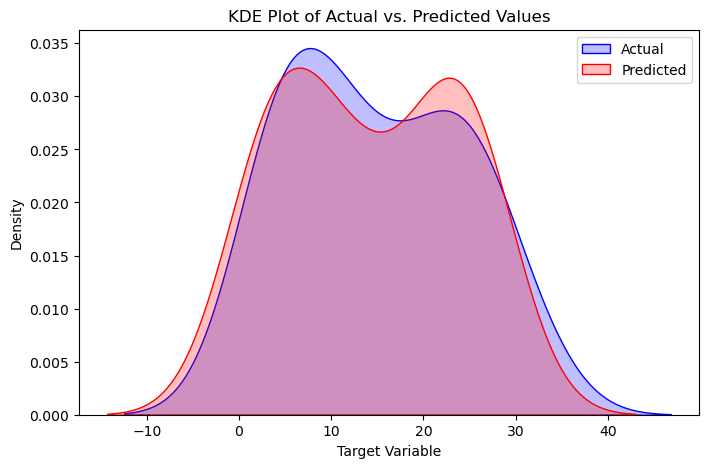

In [46]:
# Plotting KDE for Observed vs. Predicted Values
plt.figure(figsize = (8,5))
sns.kdeplot(y_test,label = 'Actual',fill = True,color = 'Blue')
sns.kdeplot(y_pred,label = 'Predicted',fill = True,color = 'Red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()

**Multiple Linear Regression**

In [47]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
lm.fit(Z,df['price'])

LinearRegression()

In [48]:
lm.intercept_

np.float64(-15806.624626329227)

In [49]:
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

In [50]:
Yhat = lm.predict(Z)
Yhat

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097, 10722.32509097, 17804.80307397,
       18063.72662867, 19320.78745066, 26968.56492801, 27674.72007721,
       28191.0677239 ,   650.62317688,  5648.50489642,  5813.27443123,
        5478.81383232,  5370.64136587,  8739.61952024,  5799.04215638,
        5902.61157827,  5902.61157827,  9036.2046829 , 11863.43973759,
       18767.70667001,  4808.3090102 ,  5693.32889063,  4006.47212651,
        6118.73075572,  6194.05397163,  6448.26982534,  6514.17763926,
        9478.65495235,  9728.16310506,  9798.77861998, 10118.90228761,
       11178.86719942, 10423.81935057,  9463.46710755, 12626.61544369,
       34470.03895495, 34470.03895495, 43996.52260522,  5265.67702191,
        5565.15645357,  5588.69495854,  5777.00299832,  5800.5415033 ,
        7337.21461795,  7337.21461795,  7360.75312292, 10536.2966792 ,
      

In [51]:
Z = df[['normalized-losses','highway-mpg']]
lm.fit(Z,df['price'])

LinearRegression()

**Model Evaluation Using Visualization**

**Regression Plot**

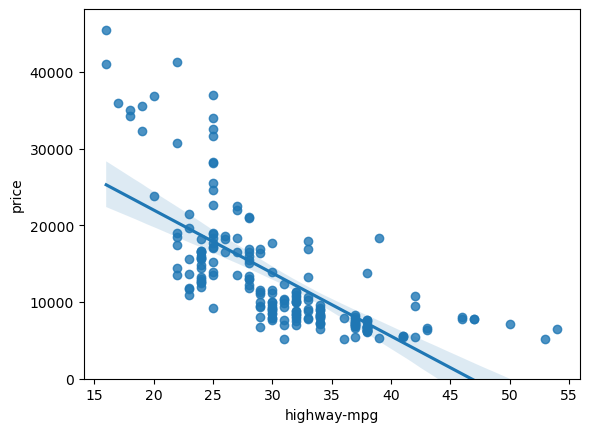

In [52]:
plt.Figure(figsize=(12,8))
sns.regplot(x="highway-mpg", y="price",data = df)
plt.ylim(0,)
plt.show()

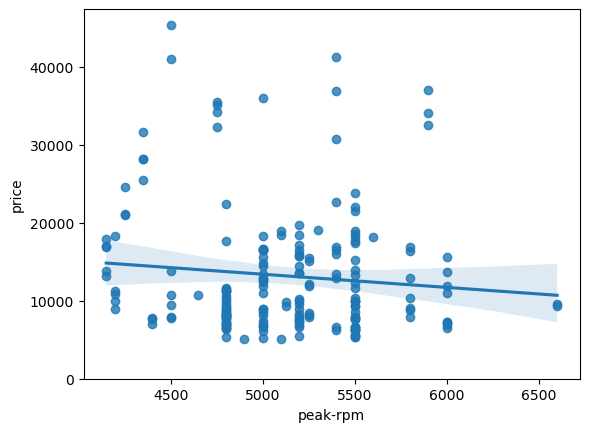

In [53]:
plt.Figure(figsize=(12,6))
sns.regplot(x="peak-rpm", y="price",data = df)
plt.ylim(0,)
plt.show()

In [54]:
df[["peak-rpm","price","highway-mpg"]].corr()

,peak-rpm,price,highway-mpg
peak-rpm,1.000000,-0.101616,-0.058598
price,-0.101616,1.000000,-0.704692
highway-mpg,-0.058598,-0.704692,1.000000
